# Assignment - 3

## Assignment Details 
-Create aotebook that uses the airquality dataset from pydataset and walks students through core pandas skills: structure, head/tail, selects, filters, missing values, duplicates, sorting, and simple aggregations.

## Practise Exercises
    - Inspecting structure: shape, dtypes, info, head, tail
    - Summary stats: describe, nunique
    - Missing values: isna, fillna (median/mean imputation)
    - Selecting columns/rows: lists, iloc, boolean masks, isin
    - Filtering with conditions and ranges 
    - Sorting by multiple columns
    - Duplicates: duplicated, drop_duplicates
    - Derived columns & categorization: arithmetic, pd.cut
    - Groupby & aggregation: agg, boolean-to-int counting
    - (Optional) quick sanity plots

In [1]:
## Few Initial Commands to help you load the data

In [1]:
# Install libraries in not availabl
import pandas as pd
import numpy as np
from pydataset import data

In [2]:
# Option A: Load directly from pydataset
df = data('airquality')

In [3]:
df.shape

(153, 6)

In [4]:
df.head(2)

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2


## Tasks

### T1. Inspect the structure
- Show the shape (rows, columns)
- List column names and dtypes
- Display the first 5 and last 5 rows

> **Hints:** `df.shape`, `df.dtypes`, `df.columns`, `df.head()`, `df.tail()`, `df.info()`

In [5]:
# Shape
df.shape

(153, 6)

In [6]:
# Column names & dtypes
df.dtypes

Ozone      float64
Solar.R    float64
Wind       float64
Temp         int64
Month        int64
Day          int64
dtype: object

In [7]:
# Head and Tails
df.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2
3,12.0,149.0,12.6,74,5,3
4,18.0,313.0,11.5,62,5,4
5,NaN,NaN,14.3,56,5,5


In [8]:
df.tail()

,Ozone,Solar.R,Wind,Temp,Month,Day
149,30.0,193.0,6.9,70,9,26
150,NaN,145.0,13.2,77,9,27
151,14.0,191.0,14.3,75,9,28
152,18.0,131.0,8.0,76,9,29
153,20.0,223.0,11.5,68,9,30


In [9]:
# Info Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 153 entries, 1 to 153
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    116 non-null    float64
 1   Solar.R  146 non-null    float64
 2   Wind     153 non-null    float64
 3   Temp     153 non-null    int64  
 4   Month    153 non-null    int64  
 5   Day      153 non-null    int64  
dtypes: float64(3), int64(3)
memory usage: 8.4 KB


### T2. Basic summary stats
- Produce descriptive statistics for numeric columns.
- For each column, show number of unique values.

> **Hints:** `df.describe()`, `df.nunique()`

In [10]:
# code for T2
df.describe()

,Ozone,Solar.R,Wind,Temp,Month,Day
count,116.000000,146.000000,153.000000,153.000000,153.000000,153.000000
mean,42.129310,185.931507,9.957516,77.882353,6.993464,15.803922
std,32.987885,90.058422,3.523001,9.465270,1.416522,8.864520
min,1.000000,7.000000,1.700000,56.000000,5.000000,1.000000
25%,18.000000,115.750000,7.400000,72.000000,6.000000,8.000000
50%,31.500000,205.000000,9.700000,79.000000,7.000000,16.000000
75%,63.250000,258.750000,11.500000,85.000000,8.000000,23.000000
max,168.000000,334.000000,20.700000,97.000000,9.000000,31.000000


In [11]:
df.nunique()

Ozone       67
Solar.R    117
Wind        31
Temp        40
Month        5
Day         31
dtype: int64

### T3. Missing values
- Count missing values per column.
- Create a copy `df_mv` where you impute:
  - `Ozone`: fill with the column median (numeric)
  - `Solar.R`: fill with the column mean (numeric)
- Briefly comment: why might median be preferred over mean in some cases? (Add a markdown cell.)

> **Hints:** `df.isna().sum()`, `df.copy()`, `fillna()`

In [12]:
# code for T3
df.isna().sum()

Ozone      37
Solar.R     7
Wind        0
Temp        0
Month       0
Day         0
dtype: int64

In [13]:
df_mv = df.copy()

In [14]:
df_mv['Ozone'] =df_mv['Ozone'].fillna(df_mv['Ozone'].median())

In [15]:
df_mv["Solar.R"] = df_mv["Solar.R"].fillna(df_mv["Solar.R"].mean())

In [19]:
print(df_mv.isna().sum())

Ozone      0
Solar.R    0
Wind       0
Temp       0
Month      0
Day        0
dtype: int64


In [16]:
print(df_mv.head())

   Ozone     Solar.R  Wind  Temp  Month  Day
1   41.0  190.000000   7.4    67      5    1
2   36.0  118.000000   8.0    72      5    2
3   12.0  149.000000  12.6    74      5    3
4   18.0  313.000000  11.5    62      5    4
5   31.5  185.931507  14.3    56      5    5


### T4. Selecting columns & rows
- Select the columns: `Ozone`, `Solar.R`, `Temp` into a new DataFrame `df_sel`.
- Select the first **10 rows** of `df_sel`.
- Select rows where `Month` is **May (5)** or **June (6)** only.

> **Hints:** Column lists, `iloc`, boolean masks, `isin`

In [17]:
df_sel = df_mv[['Ozone', 'Solar.R', 'Temp']]

In [18]:
df_sel = df_sel.iloc[:10]
print(df_sel)

    Ozone     Solar.R  Temp
1    41.0  190.000000    67
2    36.0  118.000000    72
3    12.0  149.000000    74
4    18.0  313.000000    62
5    31.5  185.931507    56
6    28.0  185.931507    66
7    23.0  299.000000    65
8    19.0   99.000000    59
9     8.0   19.000000    61
10   31.5  194.000000    69


In [19]:
df_sel.head(10)

,Ozone,Solar.R,Temp
1,41.0,190.000000,67
2,36.0,118.000000,72
3,12.0,149.000000,74
4,18.0,313.000000,62
5,31.5,185.931507,56
6,28.0,185.931507,66
7,23.0,299.000000,65
8,19.0,99.000000,59
9,8.0,19.000000,61
10,31.5,194.000000,69


In [20]:
df_months= df_mv[df_mv['Month'].isin([5,6])]
df_months

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.000000,7.4,67,5,1
2,36.0,118.000000,8.0,72,5,2
3,12.0,149.000000,12.6,74,5,3
4,18.0,313.000000,11.5,62,5,4
5,31.5,185.931507,14.3,56,5,5
6,28.0,185.931507,14.9,66,5,6
7,23.0,299.000000,8.6,65,5,7
8,19.0,99.000000,13.8,59,5,8
9,8.0,19.000000,20.1,61,5,9
10,31.5,194.000000,8.6,69,5,10


In [25]:
# code for T4

### T5. Filtering & conditions
- Filter rows where `Ozone` > 100 **and** `Temp` >= 85.
- Filter rows where `Solar.R` is missing.
- Filter rows for **July (7)** with `Ozone` between **50 and 100** (inclusive).

> **Hints:** Combined boolean conditions with `&`, `|`, parentheses; `between()`

In [21]:
# code for T5
filter_1 = df_mv[(df_mv['Ozone']>100) & (df_mv['Temp']>=85)]
filter_1

,Ozone,Solar.R,Wind,Temp,Month,Day
86,108.0,223.0,8.0,85,7,25
99,122.0,255.0,4.0,89,8,7
101,110.0,207.0,8.0,90,8,9
121,118.0,225.0,2.3,94,8,29


In [22]:
filter_2 = df[df['Solar.R'].isna()]
filter_2

,Ozone,Solar.R,Wind,Temp,Month,Day
5,NaN,NaN,14.3,56,5,5
6,28.0,NaN,14.9,66,5,6
11,7.0,NaN,6.9,74,5,11
27,NaN,NaN,8.0,57,5,27
96,78.0,NaN,6.9,86,8,4
97,35.0,NaN,7.4,85,8,5
98,66.0,NaN,4.6,87,8,6


In [23]:
filter_3 = df_mv [(df_mv ['Month'] == 7) & (df_mv['Ozone'] >= 50) & (df_mv['Ozone']<=100)]
filter_3

,Ozone,Solar.R,Wind,Temp,Month,Day
66,64.0,175.0,4.6,83,7,5
68,77.0,276.0,5.1,88,7,7
69,97.0,267.0,6.3,92,7,8
70,97.0,272.0,5.7,92,7,9
71,85.0,175.0,7.4,89,7,10
79,61.0,285.0,6.3,84,7,18
80,79.0,187.0,5.1,87,7,19
81,63.0,220.0,11.5,85,7,20
85,80.0,294.0,8.6,86,7,24
88,52.0,82.0,12.0,86,7,27


### T6. Sorting
- Sort the dataset by `Ozone` **descending** and `Temp` **ascending** (multi-column sort).
- Sort the dataset by `Month` then `Day` to get chronological order.

> **Hints:** `sort_values(by=[...], ascending=[...])`

In [29]:
# code for T6

In [24]:
sort_1 = df_mv.sort_values(by= ['Ozone','Temp'], ascending= [False, True])
sort_1.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
117,168.0,238.0,3.4,81,8,25
62,135.0,269.0,4.1,84,7,1
99,122.0,255.0,4.0,89,8,7
121,118.0,225.0,2.3,94,8,29
30,115.0,223.0,5.7,79,5,30


In [25]:
sort_1 = df_mv.sort_values(by= ['Ozone','Temp'], ascending= [True,False])
sort_1.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
21,1.0,8.000000,9.7,59,5,21
23,4.0,25.000000,9.7,61,5,23
18,6.0,78.000000,18.4,57,5,18
76,7.0,48.000000,14.3,80,7,15
11,7.0,185.931507,6.9,74,5,11


In [26]:
sort_2 = df_mv.sort_values (by=['Month','Day'], ascending= [True, True])
sort_2.head()

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.000000,7.4,67,5,1
2,36.0,118.000000,8.0,72,5,2
3,12.0,149.000000,12.6,74,5,3
4,18.0,313.000000,11.5,62,5,4
5,31.5,185.931507,14.3,56,5,5


### T7 Duplicates
- Check if there are any fully duplicated rows.
- Intentionally create a few duplicate rows (e.g., duplicate first 3 rows) into `df_dup`.
- Remove duplicates and report how many were removed.

> **Hints:** `df.duplicated()`, `pd.concat([...])`, `drop_duplicates()`

In [33]:
# code for T7

In [27]:
print(df_mv.duplicated().sum())

0


In [28]:
first_three = df_mv.iloc[:3]
first_three

,Ozone,Solar.R,Wind,Temp,Month,Day
1,41.0,190.0,7.4,67,5,1
2,36.0,118.0,8.0,72,5,2
3,12.0,149.0,12.6,74,5,3


In [29]:
df_dup = pd.concat([df_mv, first_three ])
print("New duplicate count:", df_dup.duplicated().sum())

New duplicate count: 3


In [30]:
df_clean = df_dup.drop_duplicates()

In [31]:
removed_count = len(df_dup) - len(df_clean)
print("Number of duplicates removed:",removed_count)

Number of duplicates removed: 3


### T8. Derived columns
- Create a new column `Temp_C` converting Fahrenheit to Celsius.
- Flag a new boolean column `High_Ozone` where `Ozone` > 100.
- Create a categorical column `Temp_Band` with labels: `Cool (<75F)`, `Warm (75–85F)`, `Hot (>85F)`.

> **Hints:** vectorized arithmetic, `pd.cut()`

In [39]:
# code for T8

In [32]:
df_mv["Temp_C"] =df_mv["Temp"]-32*5/9

In [33]:
df_mv[["Temp","Temp_C"]].head()

,Temp,Temp_C
1,67,49.222222
2,72,54.222222
3,74,56.222222
4,62,44.222222
5,56,38.222222


In [34]:
df_mv["High_Ozone"] = df["Ozone"]>100
df_mv

,Ozone,Solar.R,Wind,Temp,Month,Day,Temp_C,High_Ozone
1,41.0,190.000000,7.4,67,5,1,49.222222,False
2,36.0,118.000000,8.0,72,5,2,54.222222,False
3,12.0,149.000000,12.6,74,5,3,56.222222,False
4,18.0,313.000000,11.5,62,5,4,44.222222,False
5,31.5,185.931507,14.3,56,5,5,38.222222,False
6,28.0,185.931507,14.9,66,5,6,48.222222,False
7,23.0,299.000000,8.6,65,5,7,47.222222,False
8,19.0,99.000000,13.8,59,5,8,41.222222,False
9,8.0,19.000000,20.1,61,5,9,43.222222,False
10,31.5,194.000000,8.6,69,5,10,51.222222,False


In [35]:
bins = [-np.inf, 75, 85.01, np.inf]
labels = ["Cool", "Warm", "Hot"]
df["Temp_Band"] = pd.cut(
    df["Temp"], bins=bins, labels=labels, right=False
)
df.head(10)

,Ozone,Solar.R,Wind,Temp,Month,Day,Temp_Band
1,41.0,190.0,7.4,67,5,1,Cool
2,36.0,118.0,8.0,72,5,2,Cool
3,12.0,149.0,12.6,74,5,3,Cool
4,18.0,313.0,11.5,62,5,4,Cool
5,NaN,NaN,14.3,56,5,5,Cool
6,28.0,NaN,14.9,66,5,6,Cool
7,23.0,299.0,8.6,65,5,7,Cool
8,19.0,99.0,13.8,59,5,8,Cool
9,8.0,19.0,20.1,61,5,9,Cool
10,NaN,194.0,8.6,69,5,10,Cool


### T9. Groupby & aggregation
- Group by `Month` and compute **mean Ozone**, **median Solar.R**, and **max Temp**.
- Within each `Month`, count how many days have `Ozone` > 80.

> **Hints:** `groupby()`, `agg({...})`, Boolean to int conversion or `np.sum()`

In [42]:
# code for T8

In [55]:
df.groupby('Month').agg({
    'Ozone': 'mean',
    'Solar.R': 'median',
    'Temp': 'max'})

,Ozone,Solar.R,Temp
Month,,,
5,23.615385,194.0,81
6,29.444444,188.5,93
7,59.115385,253.0,92
8,59.961538,197.5,97
9,31.448276,192.0,93


In [56]:
df.groupby('Month')['Ozone'].apply(lambda x: (x > 80).sum())

Month
5    1
6    0
7    6
8    7
9    2
Name: Ozone, dtype: int64

## T10.(Stretch) Quick sanity plots *(optional)*
If permitted, create two simple charts to visualize patterns:
- Histogram of `Ozone` (after imputation, using `df_mv` if you created it).
- Line plot of `Temp` across days for **August (8)** ordered by Day.

> **Hints:** `matplotlib` basic plotting

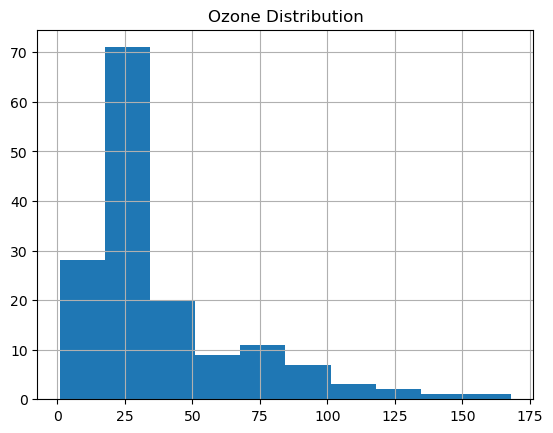

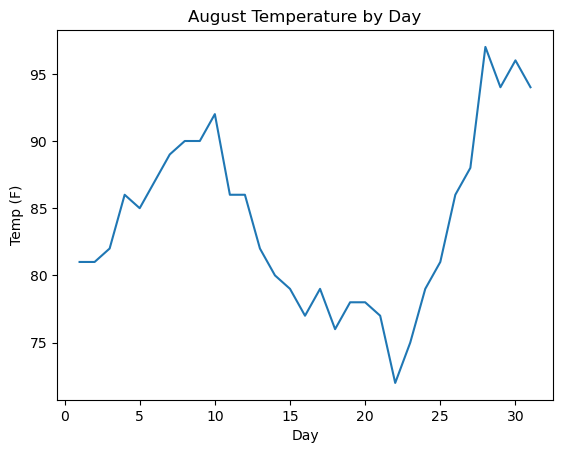

In [58]:
# Your code for Task 10 (optional) here; uncomment these lines and see
import matplotlib.pyplot as plt

# Example scaffold (uncomment and complete):
df_mv['Ozone'].hist()
plt.title('Ozone Distribution')
plt.show()

august = df[df['Month'] == 8].sort_values('Day')
plt.plot(august['Day'], august['Temp'])
plt.title('August Temperature by Day')
plt.xlabel('Day'); plt.ylabel('Temp (F)')
plt.show()

### ✅ Deliverables
- Complete all code cells under each task.
- Add **one short markdown cell** summarizing **two insights** you learned (e.g., months with higher ozone, missingness patterns, hottest months).
- (1)August was the highest Ozone Month.
- (2)The Hottest Month was August (Temp- 97)

### 📝 Evaluation (Suggested)
- **Accuracy & Correctness (40%)** – Tasks solved correctly, edge cases handled.
- **Clarity & Clean Code (20%)** – Clear variable names, comments where helpful.
- **EDA Thoroughness (20%)** – Reasonable checks and summaries beyond bare minimum.
- **Insightfulness (20%)** – Short commentary on trends/outliers/quality issues.

### Submission Format:
- Title: “PIIT Assign3 - Name” (Name your name here)
- Format: Python Notebook
### Visibility
- Git Hub Assign : https://github.com/xxxx/piit/tree/main/assign3.xxx

## Good luck & have fun!